# Analyzing Business Performance Using Demand Forecasting Techniques

## Objective

The objective of this project is to analyze weekly sales data from four retail companies:

- Bigg Bazar
- D-Mart
- Spar
- Seven Eleven

Using historical sales data, we aim to:

1. Understand sales behavior across stores and departments
2. Detect trends, seasonality, and holiday effects
3. Clean anomalies and missing values in the dataset
4. Forecast sales for the next 6 months
5. Suggest business improvements to increase performance

This project uses multiple time series forecasting techniques such as:

- Moving Average
- Exponential Smoothing
- ARIMA
- SARIMA
- Prophet
- Machine Learning Models

## Importing Required Libraries

In this section, we import all the Python libraries required for:

- Data handling
- Data visualization
- Time series forecasting
- Statistical analysis

In [2]:
# ==========================
# Data Handling Libraries
# ==========================

import pandas as pd


# ==========================
# Visualization Libraries
# ==========================

import matplotlib.pyplot as plt
import seaborn as sns


# ==========================
# Warning Handling
# ==========================

import warnings
warnings.filterwarnings("ignore")


# ==========================
# Display Settings
# ==========================

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)


# ==========================
# Plot Style
# ==========================

plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# ==========================
# Load Company Datasets
# ==========================

bigg_bazar = pd.read_csv("company1.csv")
dmart = pd.read_csv("company2.csv")
spar = pd.read_csv("company3.csv")
seven_eleven = pd.read_csv("company4.csv")


# ==========================
# Add Company Names
# ==========================

bigg_bazar["Company"] = "Bigg Bazar"
dmart["Company"] = "D-Mart"
spar["Company"] = "Spar"
seven_eleven["Company"] = "Seven Eleven"


print("All datasets loaded successfully")

All datasets loaded successfully


## Initial Data Inspection

We inspect:

- Number of rows and columns
- Column names
- Missing values
- Data types
- Sample records

This helps us understand the dataset before cleaning.

In [4]:
# ==========================
# Store datasets in dictionary
# ==========================

datasets = {
    "Bigg Bazar": bigg_bazar,
    "D-Mart": dmart,
    "Spar": spar,
    "Seven Eleven": seven_eleven
}


# ==========================
# Inspect datasets
# ==========================

for company_name, df in datasets.items():

    print("=" * 60)
    print(f"Company: {company_name}")
    print("=" * 60)

    print("\nShape of dataset:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nData Types:")
    print(df.dtypes)

    print("\nFirst 5 Rows:")
    display(df.head())

    print("\n")

Company: Bigg Bazar

Shape of dataset:
(6006, 6)

Columns:
['Date', 'Store', 'Dept', 'Weekly_Sales', 'IsHoliday', 'Company']

Missing Values:
Date            0
Store           0
Dept            0
Weekly_Sales    0
IsHoliday       0
Company         0
dtype: int64

Data Types:
Date                str
Store             int64
Dept              int64
Weekly_Sales    float64
IsHoliday          bool
Company             str
dtype: object

First 5 Rows:


,Date,Store,Dept,Weekly_Sales,IsHoliday,Company
0,2010-02-05,1,1,24924.50,False,Bigg Bazar
1,2010-02-12,1,1,46039.49,True,Bigg Bazar
2,2010-02-19,1,1,41595.55,False,Bigg Bazar
3,2010-02-26,1,1,19403.54,False,Bigg Bazar
4,2010-03-05,1,1,21827.90,False,Bigg Bazar




Company: D-Mart

Shape of dataset:
(6006, 6)

Columns:
['Date', 'Store', 'Dept', 'Weekly_Sales', 'IsHoliday', 'Company']

Missing Values:
Date            0
Store           0
Dept            0
Weekly_Sales    0
IsHoliday       0
Company         0
dtype: int64

Data Types:
Date                str
Store             int64
Dept              int64
Weekly_Sales    float64
IsHoliday          bool
Company             str
dtype: object

First 5 Rows:


,Date,Store,Dept,Weekly_Sales,IsHoliday,Company
0,2010-02-05,1,1,17426.75,False,D-Mart
1,2010-02-12,1,1,37734.82,True,D-Mart
2,2010-02-19,1,1,22135.29,False,D-Mart
3,2010-02-26,1,1,14942.21,False,D-Mart
4,2010-03-05,1,1,17098.49,False,D-Mart




Company: Spar

Shape of dataset:
(14603, 6)

Columns:
['Date', 'Store', 'Dept', 'Weekly_Sales', 'IsHoliday', 'Company']

Missing Values:
Date            0
Store           0
Dept            0
Weekly_Sales    0
IsHoliday       0
Company         0
dtype: int64

Data Types:
Date                str
Store             int64
Dept              int64
Weekly_Sales    float64
IsHoliday          bool
Company             str
dtype: object

First 5 Rows:


,Date,Store,Dept,Weekly_Sales,IsHoliday,Company
0,2010-02-05,1,1,32452.79,False,Spar
1,2010-02-12,1,1,50360.71,True,Spar
2,2010-02-19,1,1,28504.70,False,Spar
3,2010-02-26,1,1,23033.73,False,Spar
4,2010-03-05,1,1,29662.30,False,Spar




Company: Seven Eleven

Shape of dataset:
(5839, 6)

Columns:
['Date', 'Store', 'Dept', 'Weekly_Sales', 'IsHoliday', 'Company']

Missing Values:
Date            0
Store           0
Dept            0
Weekly_Sales    0
IsHoliday       0
Company         0
dtype: int64

Data Types:
Date                str
Store             int64
Dept              int64
Weekly_Sales    float64
IsHoliday          bool
Company             str
dtype: object

First 5 Rows:


,Date,Store,Dept,Weekly_Sales,IsHoliday,Company
0,2010-02-05,1,1,20347.48,False,Seven Eleven
1,2010-02-12,1,1,36644.15,True,Seven Eleven
2,2010-02-19,1,1,27545.97,False,Seven Eleven
3,2010-02-26,1,1,15768.00,False,Seven Eleven
4,2010-03-05,1,1,17335.02,False,Seven Eleven


## Converting Date Column to Datetime Format

The `Date` column is currently stored as a string.

For time series analysis, dates must be converted into datetime format so that Python can:

- understand time progression
- sort dates correctly
- detect seasonality
- create rolling statistics
- forecast future values

In [5]:
# ==========================
# Convert Date Column
# ==========================

for company_name, df in datasets.items():

    df["Date"] = pd.to_datetime(df["Date"])

    print(f"{company_name}: Date converted successfully")


print("\nAll date columns converted.")

Bigg Bazar: Date converted successfully
D-Mart: Date converted successfully
Spar: Date converted successfully
Seven Eleven: Date converted successfully

All date columns converted.


## Validating Dataset Assumptions

According to the assignment:

- Every company should have 7 stores
- Every store should have 6 departments
- Weekly sales data should exist

We validate these assumptions before cleaning.

In [6]:
# ==========================
# Validate Stores & Departments
# ==========================

for company_name, df in datasets.items():

    print("=" * 60)
    print(f"Company: {company_name}")
    print("=" * 60)

    # Unique stores
    stores = sorted(df["Store"].unique())

    print(f"\nNumber of Stores: {len(stores)}")
    print("Store IDs:", stores)

    # Departments per store
    print("\nDepartments in each Store:")

    for store in stores:

        dept_count = (
            df[df["Store"] == store]["Dept"]
            .nunique()
        )

        print(
            f"Store {store}: "
            f"{dept_count} departments"
        )

    print("\n")

Company: Bigg Bazar

Number of Stores: 7
Store IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

Departments in each Store:
Store 1: 6 departments
Store 2: 6 departments
Store 3: 6 departments
Store 4: 6 departments
Store 5: 6 departments
Store 6: 6 departments
Store 7: 6 departments


Company: D-Mart

Number of Stores: 7
Store IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

Departments in each Store:
Store 1: 6 departments
Store 2: 6 departments
Store 3: 6 departments
Store 4: 6 departments
Store 5: 6 departments
Store 6: 6 departments
Store 7: 6 departments


Company: Spar

Number of Stores: 7
Store IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

Departments in each Store:
Store 1: 6 departments
Store 2: 6 departments
Store 3: 6 departments
Store 4: 6 departments
Store 5: 6 departments
Store 6: 6 departments
Store 7: 77 departments


Comp

## Cleaning Spar Dataset

An anomaly was detected in the Spar dataset.

Store 7 contained **77 departments**, while the assignment specifies that every store should only contain **6 departments**.

To maintain consistency across all companies, only departments **1 to 6** are retained.

In [7]:
# ==========================
# Fix Spar Department Anomaly
# ==========================

print("Shape before cleaning:", spar.shape)

# Keep departments 1–6 only
spar = spar[spar["Dept"].isin([1, 2, 3, 4, 5, 6])]

print("Shape after cleaning:", spar.shape)


# Update dataset dictionary
datasets["Spar"] = spar

print("\nSpar cleaned successfully.")

Shape before cleaning: (14603, 6)
Shape after cleaning: (6006, 6)

Spar cleaned successfully.


## Detecting Missing Weekly Records in Seven Eleven

The Seven Eleven dataset contains fewer rows than expected.

To identify missing sales records, we reconstruct the expected combinations of:

- Store
- Department
- Date

Then compare against the existing data.

In [8]:
# ==========================
# Detect Missing Records
# ==========================

print("Current shape:", seven_eleven.shape)


# Get unique values
stores = seven_eleven["Store"].unique()
departments = seven_eleven["Dept"].unique()
dates = seven_eleven["Date"].unique()


# Create all expected combinations
full_index = pd.MultiIndex.from_product(
    [stores, departments, dates],
    names=["Store", "Dept", "Date"]
)


# Existing combinations
existing_index = seven_eleven.set_index(
    ["Store", "Dept", "Date"]
).index


# Find missing rows
missing_records = full_index.difference(
    existing_index
)


print("Number of missing records:")
print(len(missing_records))


# Convert properly into dataframe
missing_df = missing_records.to_frame(
    index=False
)


print("\nFirst few missing records:")
display(missing_df.head())

Current shape: (5839, 6)
Number of missing records:
167

First few missing records:


,Store,Dept,Date
0,3,5,2010-02-12
1,3,5,2010-02-19
2,3,5,2010-02-26
3,3,5,2010-03-05
4,3,5,2010-03-12


## Understanding Missing Data Pattern

Before filling missing values, we analyze:

- Which stores are affected
- Which departments are affected
- Whether missing values occur randomly or in blocks

Understanding the pattern helps choose the correct imputation method.

In [10]:
# ==========================
# Missing Records Analysis
# ==========================

print("Missing records by Store:\n")
print(
    missing_df["Store"]
    .value_counts()
    .sort_index()
)

print("\n" + "="*60)

print("\nMissing records by Department:\n")
print(
    missing_df["Dept"]
    .value_counts()
    .sort_index()
)

print("\n" + "="*60)

print("\nMissing records by Store & Department:\n")

store_dept_missing = (
    missing_df
    .groupby(["Store", "Dept"])
    .size()
    .reset_index(name="Missing_Count")
)

display(store_dept_missing)

Missing records by Store:

Store
3    154
4      8
5      5
Name: count, dtype: int64


Missing records by Department:

Dept
5     30
6    137
Name: count, dtype: int64


Missing records by Store & Department:



,Store,Dept,Missing_Count
0,3,5,30
1,3,6,124
2,4,6,8
3,5,6,5


## Reconstructing Missing Weekly Records

To maintain continuity in time series forecasting:

1. Missing Store–Department–Date combinations are recreated
2. Missing sales values are interpolated
3. Holiday information is preserved

This ensures a complete weekly time series for forecasting.

In [10]:
# ==========================
# Create Full Timeline
# ==========================

stores = sorted(
    seven_eleven["Store"].unique()
)

departments = sorted(
    seven_eleven["Dept"].unique()
)

dates = sorted(
    seven_eleven["Date"].unique()
)


full_grid = pd.MultiIndex.from_product(
    [stores, departments, dates],
    names=["Store", "Dept", "Date"]
).to_frame(index=False)


# ==========================
# Merge Existing Data
# ==========================

seven_eleven_full = full_grid.merge(
    seven_eleven,
    on=["Store", "Dept", "Date"],
    how="left"
)


print("Shape after reconstruction:")
print(seven_eleven_full.shape)


# ==========================
# Fill Company Name
# ==========================

seven_eleven_full["Company"] = (
    seven_eleven_full["Company"]
    .fillna("Seven Eleven")
)


# ==========================
# Fill Holiday Column
# ==========================

holiday_map = (
    seven_eleven
    .drop_duplicates("Date")
    .set_index("Date")["IsHoliday"]
)

seven_eleven_full["IsHoliday"] = (
    seven_eleven_full["Date"]
    .map(holiday_map)
)


# ==========================
# Sort Time Series
# ==========================

seven_eleven_full = (
    seven_eleven_full
    .sort_values(
        by=["Store", "Dept", "Date"]
    )
)


# ==========================
# Interpolate Sales
# ==========================

seven_eleven_full["Weekly_Sales"] = (
    seven_eleven_full
    .groupby(["Store", "Dept"])[
        "Weekly_Sales"
    ]
    .transform(
        lambda x: x.interpolate(
            method="linear"
        )
    )
)


print("\nMissing sales after interpolation:")
print(
    seven_eleven_full[
        "Weekly_Sales"
    ].isnull().sum()
)

Shape after reconstruction:
(6006, 6)

Missing sales after interpolation:
31


## Handling Remaining Missing Sales Values

Interpolation may fail at the beginning or end of a time series because neighboring values are unavailable.

To handle this:

1. Forward Fill (`ffill`) uses previous week's sales
2. Backward Fill (`bfill`) uses next available week's sales

This ensures no missing values remain.

In [11]:
# ==========================
# Fill Remaining Null Values
# ==========================

seven_eleven_full["Weekly_Sales"] = (

    seven_eleven_full
    .groupby(["Store", "Dept"])["Weekly_Sales"]

    .transform(
        lambda x:
        x.ffill().bfill()
    )
)


# ==========================
# Final Null Check
# ==========================

print("Remaining missing values:\n")

print(
    seven_eleven_full
    .isnull()
    .sum()
)

Remaining missing values:

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Company         0
dtype: int64


In [12]:
# Replace old dataset
seven_eleven = seven_eleven_full

datasets["Seven Eleven"] = (
    seven_eleven
)

print("Seven Eleven cleaned successfully.")

Seven Eleven cleaned successfully.


In [13]:
# ==========================
# Final Validation
# ==========================

for company_name, df in datasets.items():

    print("="*60)
    print(company_name)
    print("="*60)

    print("Shape:", df.shape)

    print(
        "\nMissing values:\n",
        df.isnull().sum()
    )

    print(
        "\nStores:",
        df["Store"].nunique()
    )

    print(
        "Departments:",
        df["Dept"].nunique()
    )

    print("\n")

Bigg Bazar
Shape: (6006, 6)

Missing values:
 Date            0
Store           0
Dept            0
Weekly_Sales    0
IsHoliday       0
Company         0
dtype: int64

Stores: 7
Departments: 6


D-Mart
Shape: (6006, 6)

Missing values:
 Date            0
Store           0
Dept            0
Weekly_Sales    0
IsHoliday       0
Company         0
dtype: int64

Stores: 7
Departments: 6


Spar
Shape: (6006, 6)

Missing values:
 Date            0
Store           0
Dept            0
Weekly_Sales    0
IsHoliday       0
Company         0
dtype: int64

Stores: 7
Departments: 6


Seven Eleven
Shape: (6006, 6)

Missing values:
 Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Company         0
dtype: int64

Stores: 7
Departments: 6




In [14]:
# ==========================
# Map Store IDs to Cities
# ==========================

city_mapping = {

    1: "Delhi",
    2: "Mumbai",
    3: "Kolkata",
    4: "Lucknow",
    5: "Bangalore",
    6: "Indore",
    7: "Jaipur"
}


# Add City Column
for company_name, df in datasets.items():

    df["City"] = (
        df["Store"]
        .map(city_mapping)
    )


print("City mapping added.")

City mapping added.


## Combining All Company Data

To make analysis easier, we combine all cleaned datasets into a single dataframe.

This allows us to:

- compare companies
- compare stores
- analyze department behavior
- build forecasting pipelines efficiently

In [15]:
# ==========================
# Combine All Companies
# ==========================

full_data = pd.concat(
    datasets.values(),
    ignore_index=True
)


print("Combined dataset shape:")
print(full_data.shape)

print("\nCompanies:")
print(full_data["Company"].unique())

Combined dataset shape:
(24024, 7)

Companies:
<StringArray>
['Bigg Bazar', 'D-Mart', 'Spar', 'Seven Eleven']
Length: 4, dtype: str


## Dataset Overview

We examine:

- total sales
- number of stores
- departments
- date range

In [16]:
# ==========================
# Dataset Overview
# ==========================

print("Total Rows:")
print(len(full_data))

print("\nDate Range:")
print(
    full_data["Date"].min(),
    "to",
    full_data["Date"].max()
)

print("\nNumber of Companies:")
print(
    full_data["Company"]
    .nunique()
)

print("\nNumber of Stores:")
print(
    full_data["Store"]
    .nunique()
)

print("\nDepartments:")
print(
    sorted(
        full_data["Dept"]
        .unique()
    )
)

Total Rows:
24024

Date Range:
2010-02-05 00:00:00 to 2012-10-26 00:00:00

Number of Companies:
4

Number of Stores:
7

Departments:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


Company
D-Mart          1.583689e+08
Spar            1.396094e+08
Bigg Bazar      1.349324e+08
Seven Eleven    8.889444e+07
Name: Weekly_Sales, dtype: float64


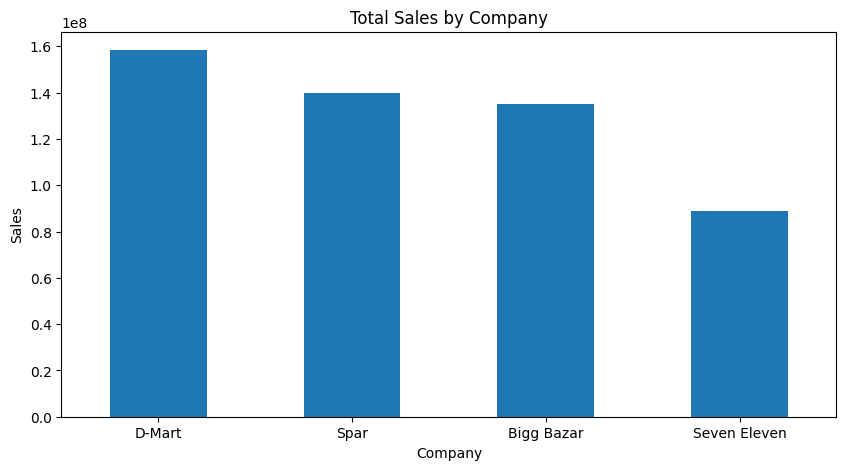

In [17]:
# ==========================
# Company-wise Total Sales
# ==========================

company_sales = (

    full_data

    .groupby("Company")[
        "Weekly_Sales"
    ]

    .sum()

    .sort_values(
        ascending=False
    )
)


print(company_sales)


# ==========================
# Plot
# ==========================

plt.figure(figsize=(10, 5))

company_sales.plot(
    kind="bar"
)

plt.title(
    "Total Sales by Company"
)

plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

## Weekly Sales Trend by Company

This helps identify:

- growth trend
- seasonality
- sudden spikes
- business stability

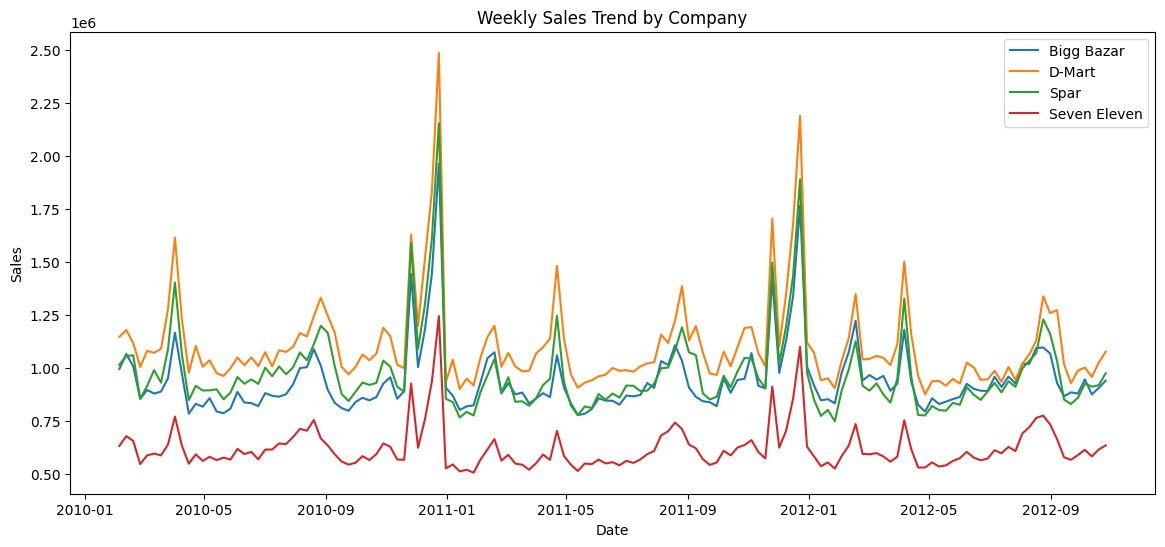

In [ ]:
# ==========================
# Weekly Company Trends
# ==========================

weekly_company_sales = (

    full_data

    .groupby(
        ["Date", "Company"]
    )["Weekly_Sales"]

    .sum()

    .reset_index()
)


plt.figure(figsize=(14, 6))

for company in full_data[
    "Company"
].unique():

    temp = weekly_company_sales[
        weekly_company_sales["Company"] == company
    ]

    plt.plot(
        temp["Date"],
        temp["Weekly_Sales"],
        label=company
    )


plt.title(
    "Weekly Sales Trend by Company"
)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

City
Mumbai       1.025666e+08
Indore       9.201059e+07
Delhi        8.889481e+07
Lucknow      7.051388e+07
Jaipur       5.872115e+07
Kolkata      5.784176e+07
Bangalore    5.125622e+07
Name: Weekly_Sales, dtype: float64


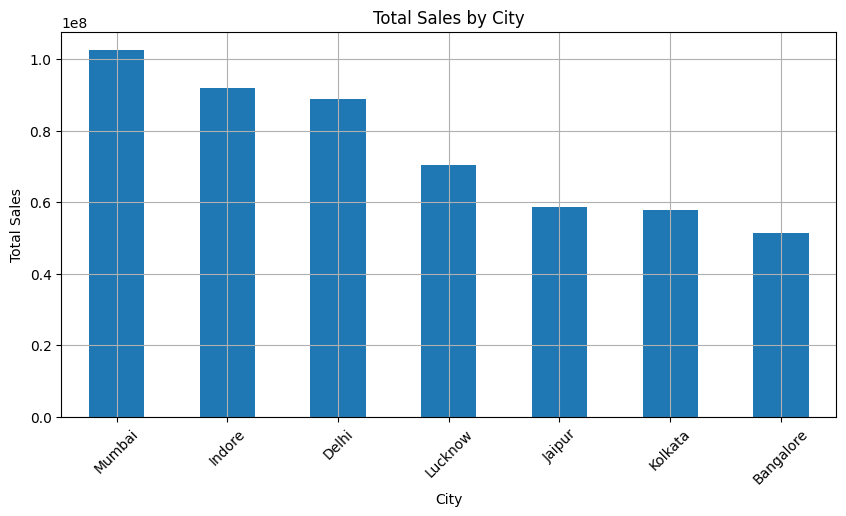

In [26]:
# ==========================
# City-wise Sales
# ==========================

city_sales = (

    full_data

    .groupby("City")[
        "Weekly_Sales"
    ]

    .sum()

    .sort_values(
        ascending=False
    )
)


print(city_sales)


# ==========================
# Visualization
# ==========================

plt.figure(figsize=(10, 5))

city_sales.plot(
    kind="bar"
)

plt.title(
    "Total Sales by City"
)

plt.xlabel("City")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

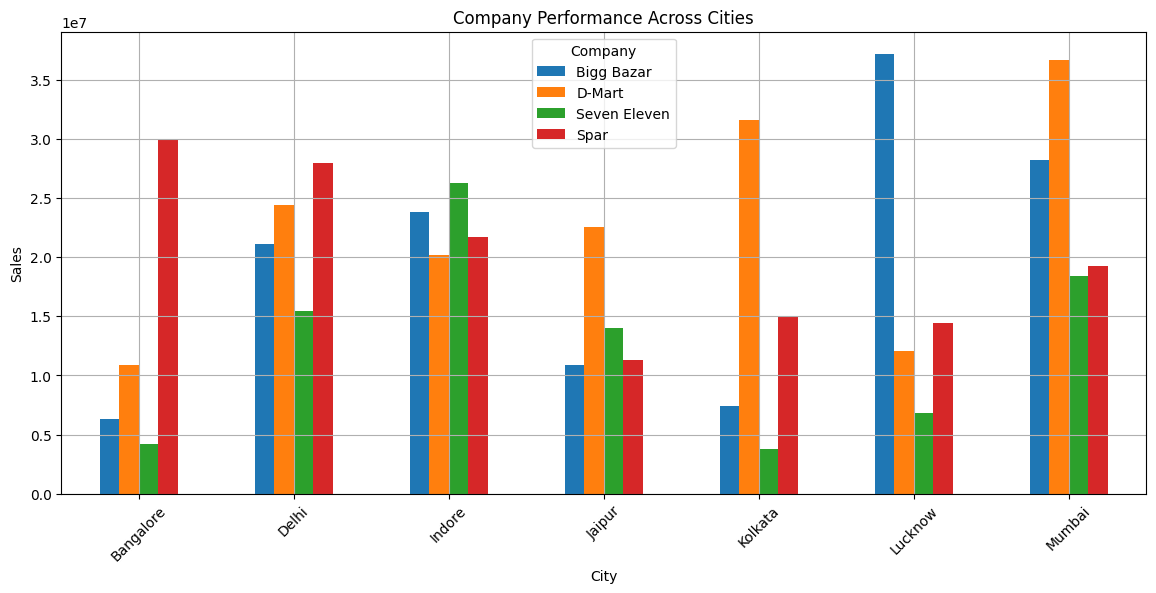

In [27]:
# ==========================
# Company vs City
# ==========================

company_city_sales = (

    full_data

    .groupby(
        ["City", "Company"]
    )["Weekly_Sales"]

    .sum()

    .reset_index()
)


pivot_sales = (

    company_city_sales

    .pivot(
        index="City",
        columns="Company",
        values="Weekly_Sales"
    )
)


pivot_sales.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title(
    "Company Performance Across Cities"
)

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

,Company,IsHoliday,Weekly_Sales
0,Bigg Bazar,False,22258.545392
1,Bigg Bazar,True,25228.873810
2,D-Mart,False,26115.418244
3,D-Mart,True,29733.671000
4,Seven Eleven,False,14694.968689
5,Seven Eleven,True,16210.353608
6,Spar,False,23017.058459
7,Spar,True,26276.403333


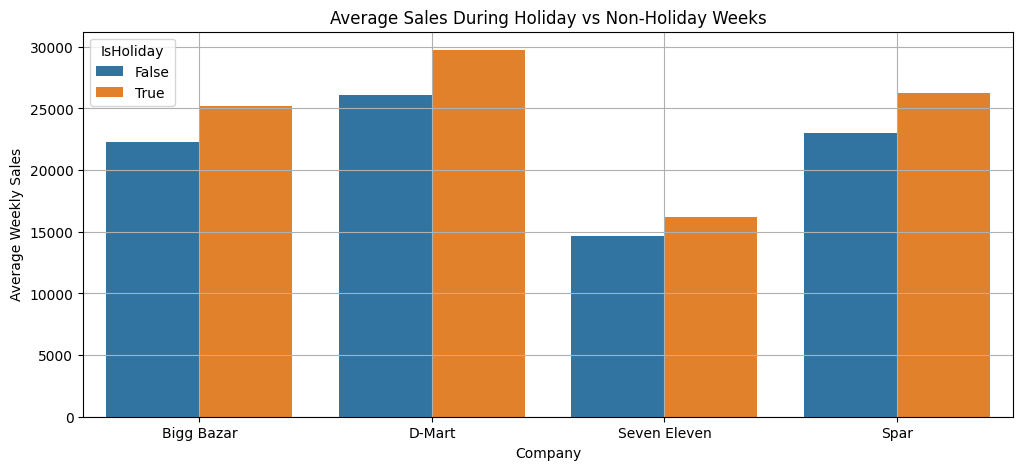

In [28]:
# ==========================
# Holiday Impact Analysis
# ==========================

holiday_sales = (

    full_data

    .groupby(
        ["Company", "IsHoliday"]
    )["Weekly_Sales"]

    .mean()

    .reset_index()
)


display(holiday_sales)


# ==========================
# Visualization
# ==========================

plt.figure(figsize=(12, 5))

sns.barplot(
    data=holiday_sales,
    x="Company",
    y="Weekly_Sales",
    hue="IsHoliday"
)

plt.title(
    "Average Sales During Holiday vs Non-Holiday Weeks"
)

plt.ylabel("Average Weekly Sales")

plt.grid(True)

plt.show()

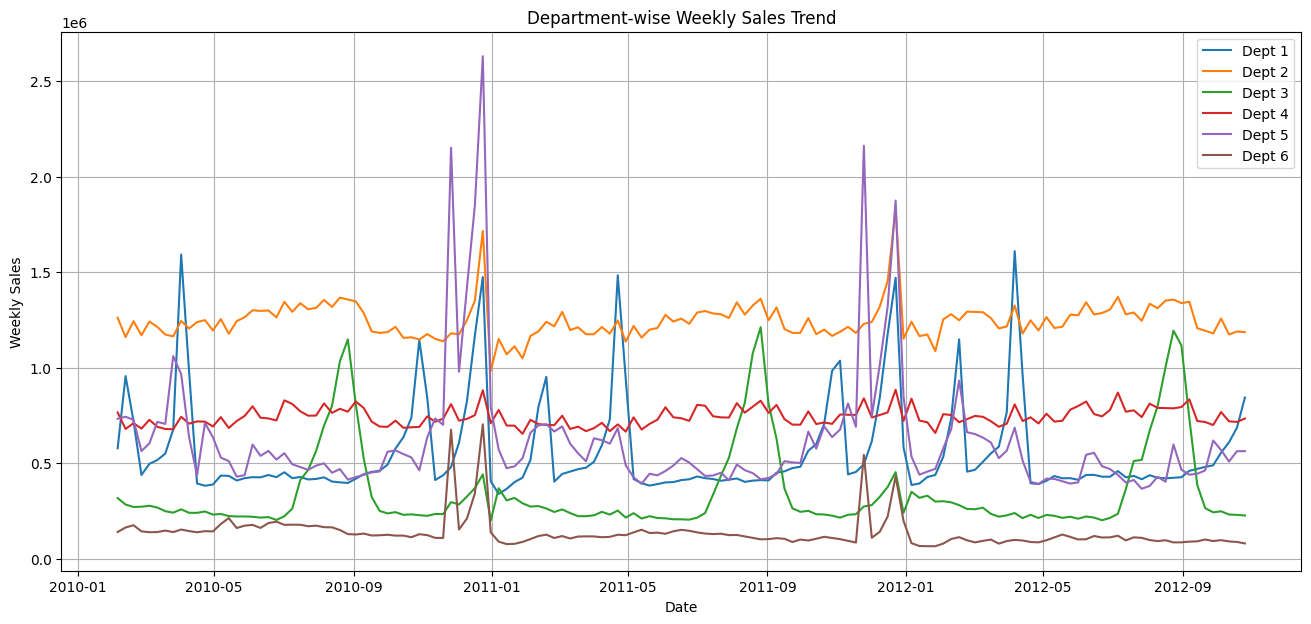

In [29]:
# ==========================
# Department Weekly Trends
# ==========================

dept_sales = (

    full_data

    .groupby(
        ["Date", "Dept"]
    )["Weekly_Sales"]

    .sum()

    .reset_index()
)


plt.figure(figsize=(16, 7))

for dept in sorted(
    full_data["Dept"].unique()
):

    temp = dept_sales[
        dept_sales["Dept"] == dept
    ]

    plt.plot(
        temp["Date"],
        temp["Weekly_Sales"],
        label=f"Dept {dept}"
    )


plt.title(
    "Department-wise Weekly Sales Trend"
)

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

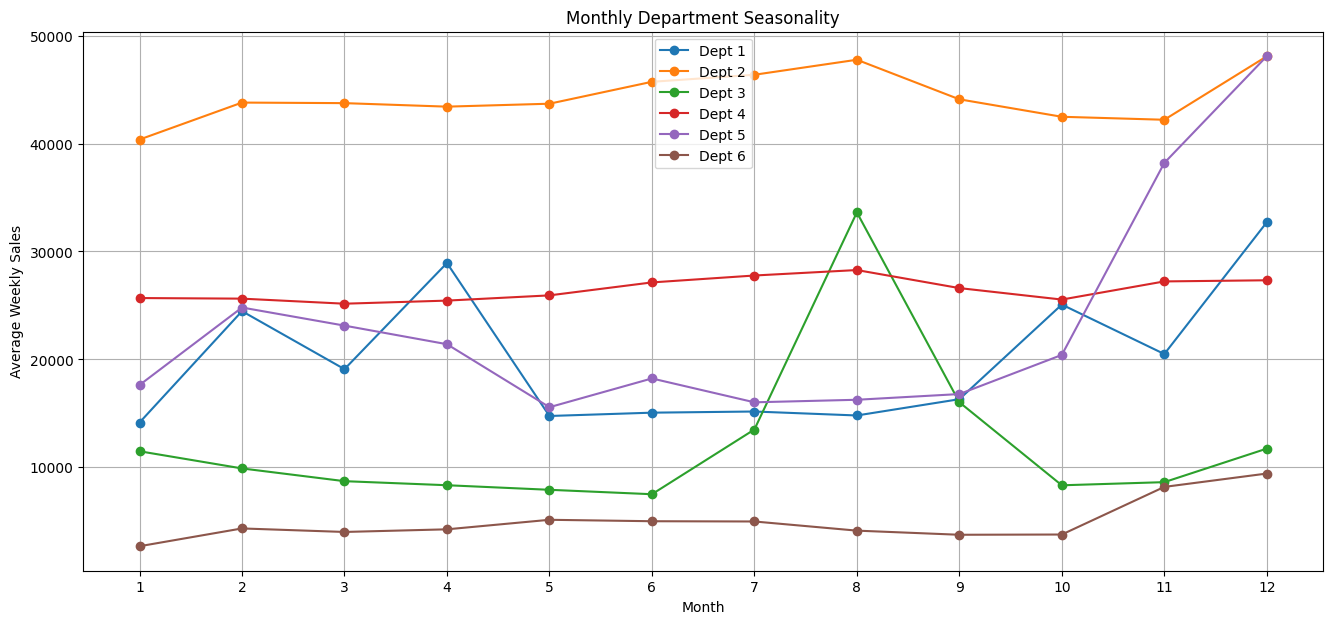

In [30]:
# ==========================
# Create Month Column
# ==========================

full_data["Month"] = (
    full_data["Date"]
    .dt.month
)


# ==========================
# Monthly Sales by Department
# ==========================

monthly_dept_sales = (

    full_data

    .groupby(
        ["Month", "Dept"]
    )["Weekly_Sales"]

    .mean()

    .reset_index()
)


plt.figure(figsize=(16, 7))


for dept in sorted(
    full_data["Dept"].unique()
):

    temp = monthly_dept_sales[
        monthly_dept_sales[
            "Dept"
        ] == dept
    ]

    plt.plot(
        temp["Month"],
        temp["Weekly_Sales"],
        marker="o",
        label=f"Dept {dept}"
    )


plt.title(
    "Monthly Department Seasonality"
)

plt.xlabel("Month")

plt.ylabel(
    "Average Weekly Sales"
)

plt.xticks(range(1, 13))

plt.legend()

plt.grid(True)

plt.show()

## Holiday Impact by Department

This analysis compares average sales during:

- Holiday weeks
- Non-holiday weeks

for every department.

The goal is to infer hidden department identities based on consumer buying behavior.

,Dept,IsHoliday,Weekly_Sales
0,1,False,20002.420572
1,1,True,20677.387143
2,2,False,44552.645193
3,2,True,43270.171214
4,3,False,12248.165983
5,3,True,13361.905286
6,4,False,26415.202320
7,4,True,27275.377821
8,5,False,21306.496669
9,5,True,33522.226403


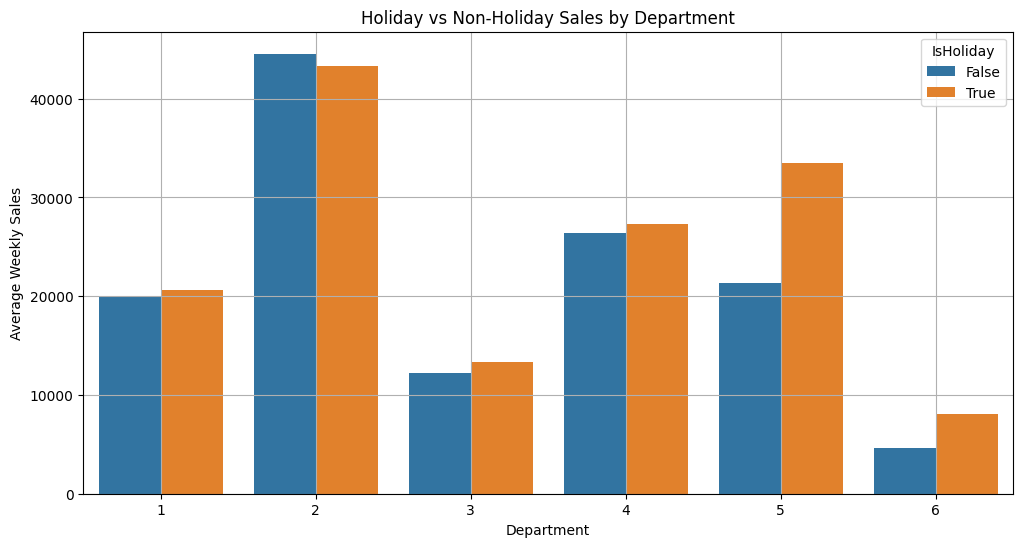

In [31]:
# ==========================
# Holiday Effect by Department
# ==========================

dept_holiday_sales = (

    full_data

    .groupby(
        ["Dept", "IsHoliday"]
    )["Weekly_Sales"]

    .mean()

    .reset_index()
)


display(dept_holiday_sales)


# ==========================
# Visualization
# ==========================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=dept_holiday_sales,
    x="Dept",
    y="Weekly_Sales",
    hue="IsHoliday"
)

plt.title(
    "Holiday vs Non-Holiday Sales by Department"
)

plt.xlabel("Department")

plt.ylabel(
    "Average Weekly Sales"
)

plt.grid(True)

plt.show()

In [18]:
# ==========================
# Department Name Mapping
# ==========================

department_mapping = {

    1: "Clothing & Apparel",
    2: "Groceries",
    3: "Books & Stationary",
    4: "Beverages",
    5: "Electronics",
    6: "Furniture"
}


full_data["Department_Name"] = (

    full_data["Dept"]
    .map(department_mapping)
)


print("Department mapping added.")

display(
    full_data[
        ["Dept", "Department_Name"]
    ].drop_duplicates()
)

Department mapping added.


,Dept,Department_Name
0,1,Clothing & Apparel
143,2,Groceries
286,3,Books & Stationary
429,4,Beverages
572,5,Electronics
715,6,Furniture


## Time Series Decomposition

A time series is usually made of:

1. Trend → Long-term movement
2. Seasonality → Repeating pattern
3. Residual → Random noise

Understanding these helps choose better forecasting models.

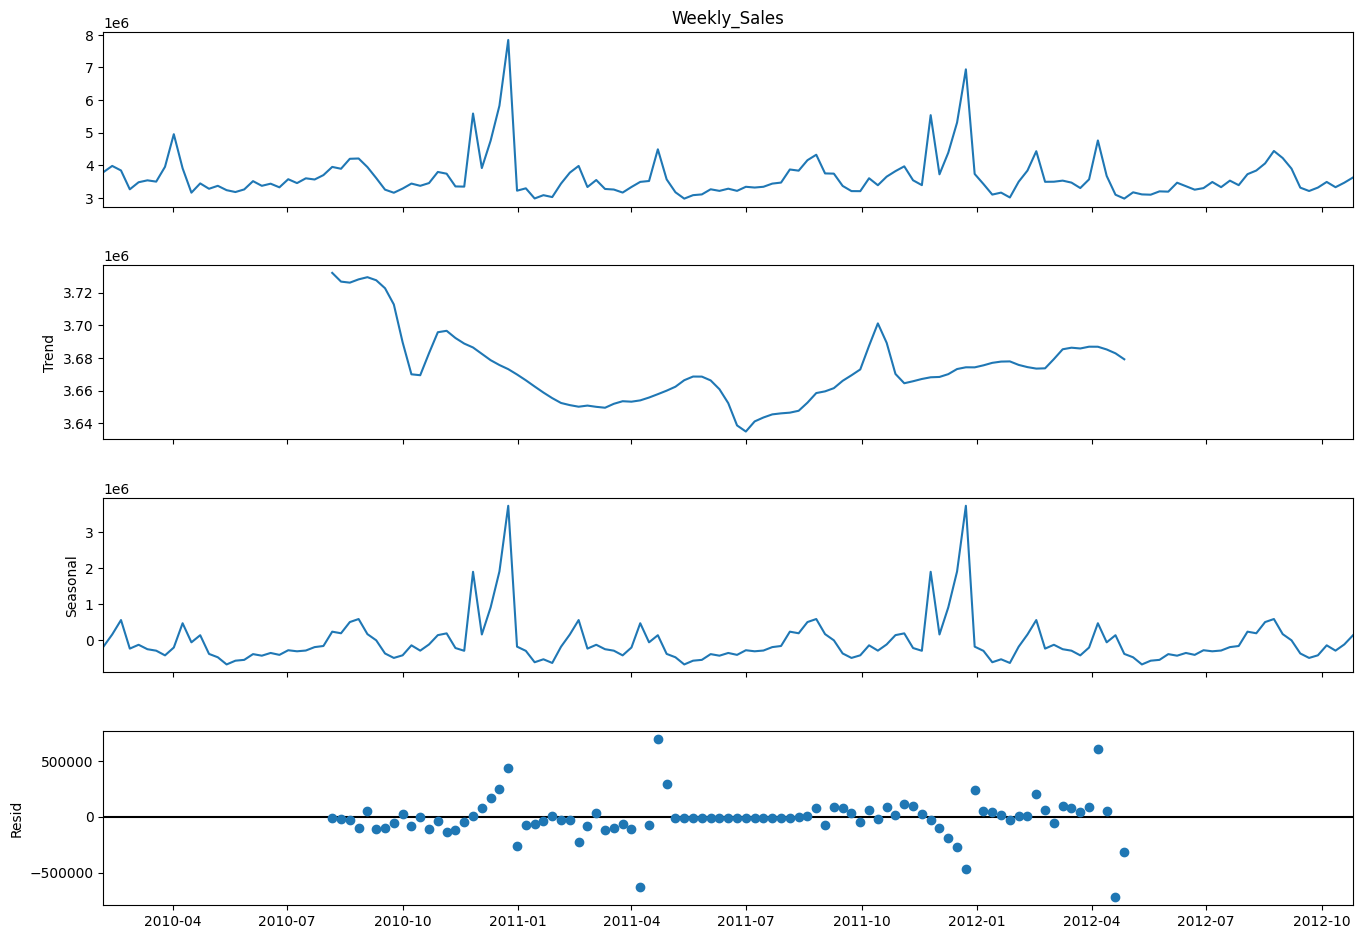

In [19]:
# ==========================
# Time Series Decomposition
# ==========================

from statsmodels.tsa.seasonal import seasonal_decompose


# Weekly total sales
weekly_sales = (

    full_data

    .groupby("Date")[
        "Weekly_Sales"
    ]

    .sum()
)


# Decompose
decomposition = seasonal_decompose(
    weekly_sales,
    model="additive",
    period=52
)


# Plot
fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.show()

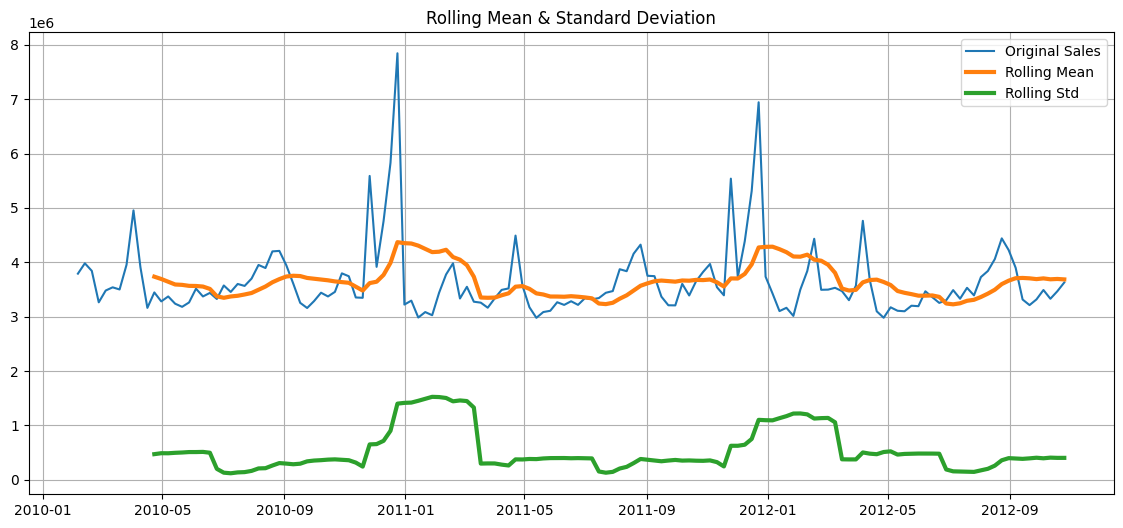

In [20]:
# ==========================
# Rolling Statistics
# ==========================

rolling_mean = (
    weekly_sales
    .rolling(window=12)
    .mean()
)

rolling_std = (
    weekly_sales
    .rolling(window=12)
    .std()
)


plt.figure(figsize=(14, 6))

plt.plot(
    weekly_sales,
    label="Original Sales"
)

plt.plot(
    rolling_mean,
    label="Rolling Mean",
    linewidth=3
)

plt.plot(
    rolling_std,
    label="Rolling Std",
    linewidth=3
)

plt.title(
    "Rolling Mean & Standard Deviation"
)

plt.legend()

plt.grid(True)

plt.show()

In [21]:
# ==========================
# ADF Test
# ==========================

from statsmodels.tsa.stattools import adfuller


result = adfuller(
    weekly_sales
)


print("ADF Statistic:")
print(result[0])

print("\np-value:")
print(result[1])

print("\nCritical Values:")

for key, value in result[4].items():

    print(
        f"{key}: {value}"
    )

ADF Statistic:
-6.040980769708029

p-value:
1.346225978214858e-07

Critical Values:
1%: -3.47864788917503
5%: -2.882721765644168
10%: -2.578065326612056


In [22]:
# ==========================
# Train-Test Split
# ==========================

split_index = int(
    len(weekly_sales) * 0.8
)


train = weekly_sales[
    :split_index
]

test = weekly_sales[
    split_index:
]


print("Training Data Size:")
print(len(train))

print("\nTesting Data Size:")
print(len(test))

Training Data Size:
114

Testing Data Size:
29


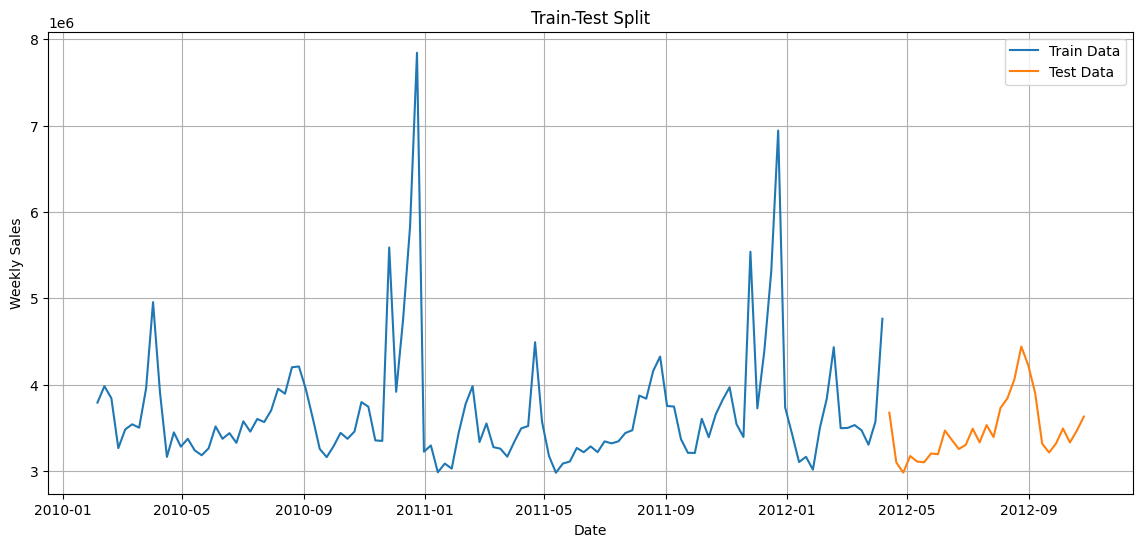

In [23]:
# ==========================
# Plot Train-Test Split
# ==========================

plt.figure(figsize=(14, 6))

plt.plot(
    train,
    label="Train Data"
)

plt.plot(
    test,
    label="Test Data"
)

plt.title(
    "Train-Test Split"
)

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

In [25]:
# ==========================
# Moving Average Forecast
# ==========================
import numpy as np
window_size = 12


# Forecast using rolling mean
moving_avg_forecast = (

    train

    .rolling(window=window_size)

    .mean()

    .iloc[-1]
)


# Predict for test period
ma_predictions = np.repeat(
    moving_avg_forecast,
    len(test)
)


print("Moving Average Forecast Value:")
print(moving_avg_forecast)

Moving Average Forecast Value:
3630734.125


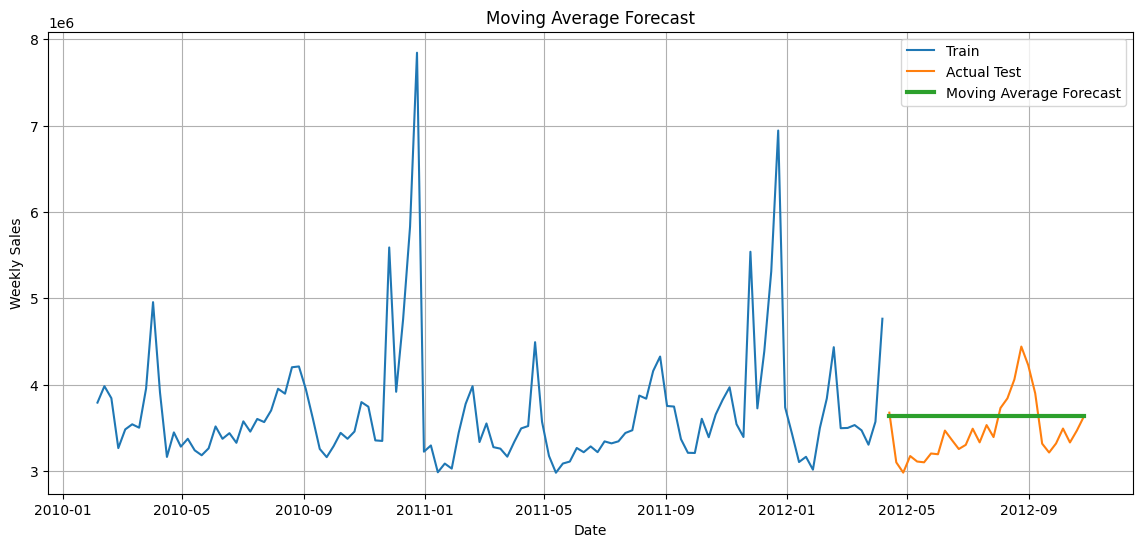

In [26]:
# ==========================
# Plot Forecast
# ==========================

plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train,
    label="Train"
)

plt.plot(
    test.index,
    test,
    label="Actual Test"
)

plt.plot(
    test.index,
    ma_predictions,
    label="Moving Average Forecast",
    linewidth=3
)

plt.title(
    "Moving Average Forecast"
)

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

In [27]:
# ==========================
# Evaluation Metrics
# ==========================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


# MAE
mae_ma = mean_absolute_error(
    test,
    ma_predictions
)


# RMSE
rmse_ma = np.sqrt(
    mean_squared_error(
        test,
        ma_predictions
    )
)


# MAPE
mape_ma = np.mean(

    np.abs(
        (
            test -
            ma_predictions
        ) / test
    )

) * 100


print("Moving Average Results")
print("-" * 40)

print(f"MAE: {mae_ma:.2f}")

print(f"RMSE: {rmse_ma:.2f}")

print(f"MAPE: {mape_ma:.2f}%")

Moving Average Results
----------------------------------------
MAE: 330993.92
RMSE: 381027.96
MAPE: 9.69%


In [28]:
# ==========================
# Exponential Smoothing
# ==========================

from statsmodels.tsa.holtwinters import (
    ExponentialSmoothing
)


# Train model
exp_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=52
)


exp_fit = exp_model.fit()


# Forecast
exp_predictions = exp_fit.forecast(
    len(test)
)


print(
    "Exponential Smoothing Model Trained"
)

Exponential Smoothing Model Trained


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


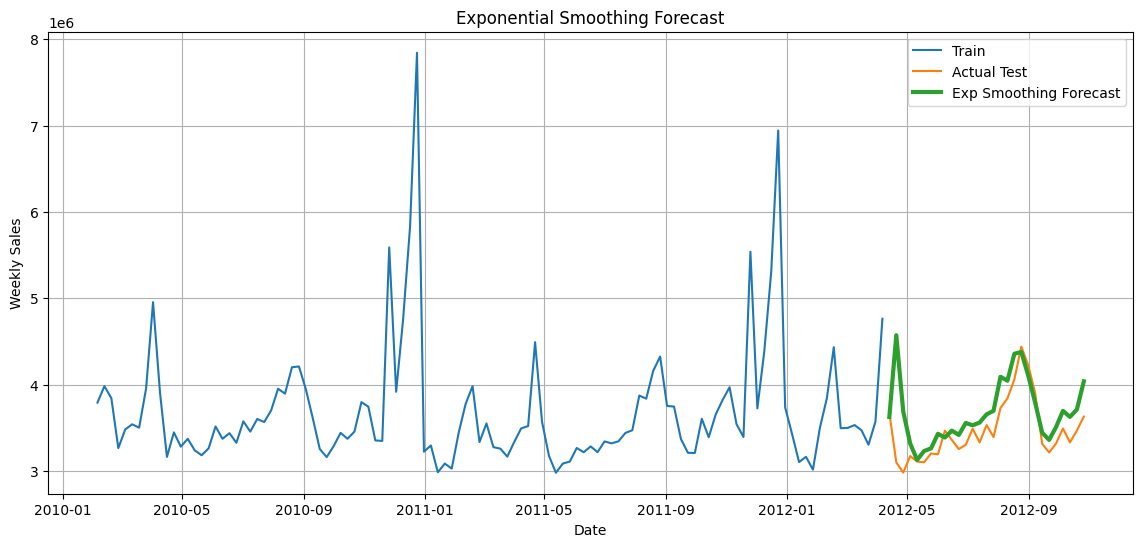

In [29]:
# ==========================
# Forecast Plot
# ==========================

plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train,
    label="Train"
)

plt.plot(
    test.index,
    test,
    label="Actual Test"
)

plt.plot(
    test.index,
    exp_predictions,
    label="Exp Smoothing Forecast",
    linewidth=3
)

plt.title(
    "Exponential Smoothing Forecast"
)

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

In [30]:
# ==========================
# Evaluation
# ==========================

mae_exp = mean_absolute_error(
    test,
    exp_predictions
)

rmse_exp = np.sqrt(
    mean_squared_error(
        test,
        exp_predictions
    )
)

mape_exp = np.mean(

    np.abs(
        (
            test -
            exp_predictions
        ) / test
    )

) * 100


print(
    "Exponential Smoothing Results"
)

print("-" * 40)

print(f"MAE: {mae_exp:.2f}")

print(f"RMSE: {rmse_exp:.2f}")

print(f"MAPE: {mape_exp:.2f}%")

Exponential Smoothing Results
----------------------------------------
MAE: 237834.59
RMSE: 360249.29
MAPE: 7.13%


In [31]:
# ==========================
# ARIMA Model
# ==========================

from statsmodels.tsa.arima.model import ARIMA


# Train ARIMA
arima_model = ARIMA(
    train,
    order=(2, 0, 2)
)


arima_fit = arima_model.fit()


# Forecast
arima_predictions = (
    arima_fit.forecast(
        steps=len(test)
    )
)


print("ARIMA model trained.")

ARIMA model trained.


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


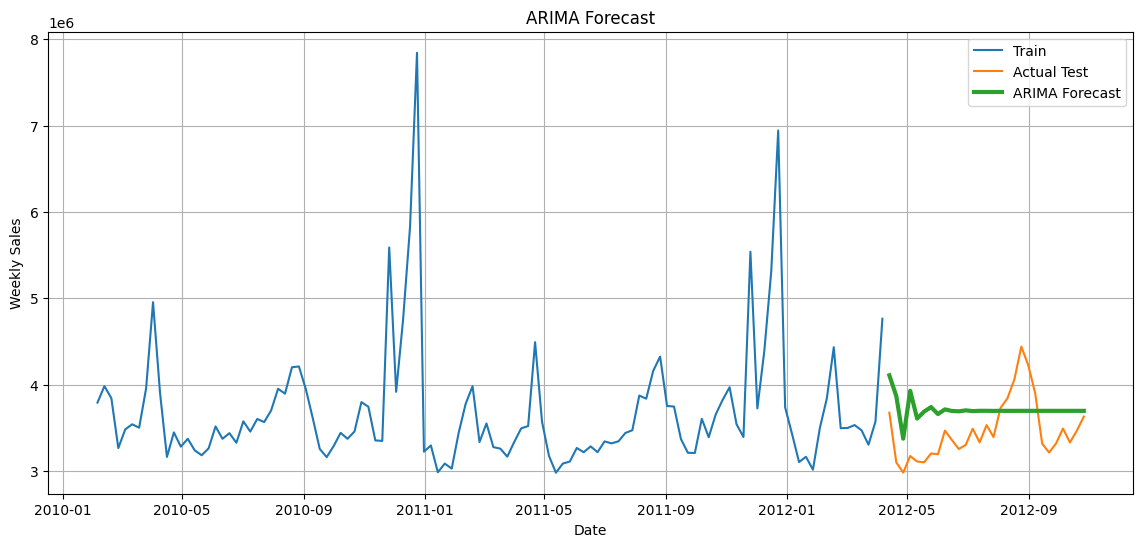

In [32]:
# ==========================
# Forecast Plot
# ==========================

plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train,
    label="Train"
)

plt.plot(
    test.index,
    test,
    label="Actual Test"
)

plt.plot(
    test.index,
    arima_predictions,
    label="ARIMA Forecast",
    linewidth=3
)

plt.title(
    "ARIMA Forecast"
)

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

In [33]:
# ==========================
# Evaluation
# ==========================

mae_arima = mean_absolute_error(
    test,
    arima_predictions
)

rmse_arima = np.sqrt(
    mean_squared_error(
        test,
        arima_predictions
    )
)

mape_arima = np.mean(

    np.abs(
        (
            test -
            arima_predictions
        ) / test
    )

) * 100


print("ARIMA Results")
print("-" * 40)

print(f"MAE: {mae_arima:.2f}")

print(f"RMSE: {rmse_arima:.2f}")

print(f"MAPE: {mape_arima:.2f}%")

ARIMA Results
----------------------------------------
MAE: 379929.25
RMSE: 423525.98
MAPE: 11.18%


In [37]:
# ==========================
# Prepare Weekly Sales Series
# ==========================

weekly_sales = (
    full_data
    .groupby("Date")["Weekly_Sales"]
    .sum()
    .sort_index()
)

# Force weekly frequency
weekly_sales = weekly_sales.asfreq("W-FRI")

# Fill any tiny gaps if present
weekly_sales = weekly_sales.interpolate()


# ==========================
# Train-Test Split
# ==========================

split_index = int(len(weekly_sales) * 0.8)

train = weekly_sales[:split_index]
test = weekly_sales[split_index:]


# ==========================
# Log Transform
# ==========================

train_log = np.log1p(train)


# ==========================
# Safer SARIMA Model
# ==========================

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_log,
    order=(1, 0, 1),
    seasonal_order=(0, 0, 1, 52),
    enforce_stationarity=True,
    enforce_invertibility=True
)

sarima_fit = sarima_model.fit(disp=False)

sarima_log_pred = sarima_fit.get_forecast(steps=len(test)).predicted_mean

# Convert back from log scale
sarima_predictions = np.expm1(sarima_log_pred)

print("SARIMA model trained successfully.")

SARIMA model trained successfully.


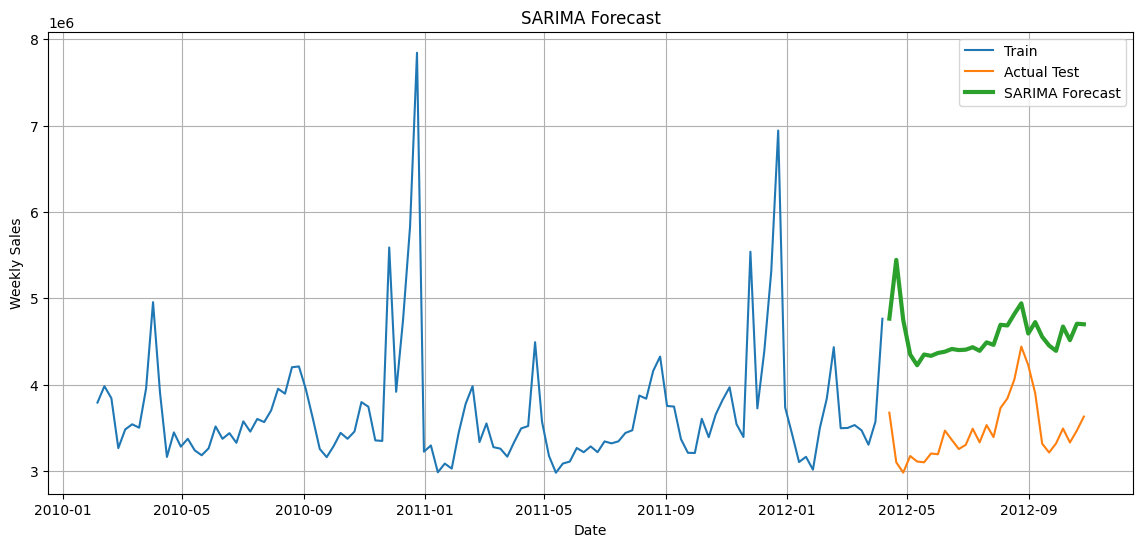

In [38]:
# ==========================
# Forecast Plot
# ==========================

plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train,
    label="Train"
)

plt.plot(
    test.index,
    test,
    label="Actual Test"
)

plt.plot(
    test.index,
    sarima_predictions,
    label="SARIMA Forecast",
    linewidth=3
)

plt.title(
    "SARIMA Forecast"
)

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

In [39]:
mae_sarima = mean_absolute_error(test, sarima_predictions)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_predictions))
mape_sarima = np.mean(np.abs((test - sarima_predictions) / test)) * 100

print("SARIMA Results")
print("-" * 40)
print(f"MAE: {mae_sarima:.2f}")
print(f"RMSE: {rmse_sarima:.2f}")
print(f"MAPE: {mape_sarima:.2f}%")

SARIMA Results
----------------------------------------
MAE: 1095978.69
RMSE: 1147631.43
MAPE: 32.58%


In [46]:
%pip install prophet

  Using cached prophet-1.3.0-py3-none-macosx_11_0_arm64.whl.metadata (3.5 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-macosx_11_0_arm64.whl (12.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.2 MB/s  0:00:01 eta 0:00:01
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [prophet]m5/6 [prophet]]

[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [47]:
# ==========================
# Prophet Data
# ==========================

prophet_train = train.reset_index()

prophet_train.columns = [
    "ds",
    "y"
]


prophet_test = test.reset_index()

prophet_test.columns = [
    "ds",
    "y"
]

In [48]:
# ==========================
# Prophet Model
# ==========================

from prophet import Prophet


prophet_model = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=False,

    daily_seasonality=False
)


# Fit
prophet_model.fit(
    prophet_train
)


# Future dataframe
future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq="W"
)


# Predict
forecast = prophet_model.predict(
    future
)


# Extract predictions
prophet_predictions = forecast[
    "yhat"
].iloc[-len(test):].values


print(
    "Prophet model trained."
)

Importing plotly failed. Interactive plots will not work.
17:40:29 - cmdstanpy - INFO - Chain [1] start processing
17:40:29 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained.


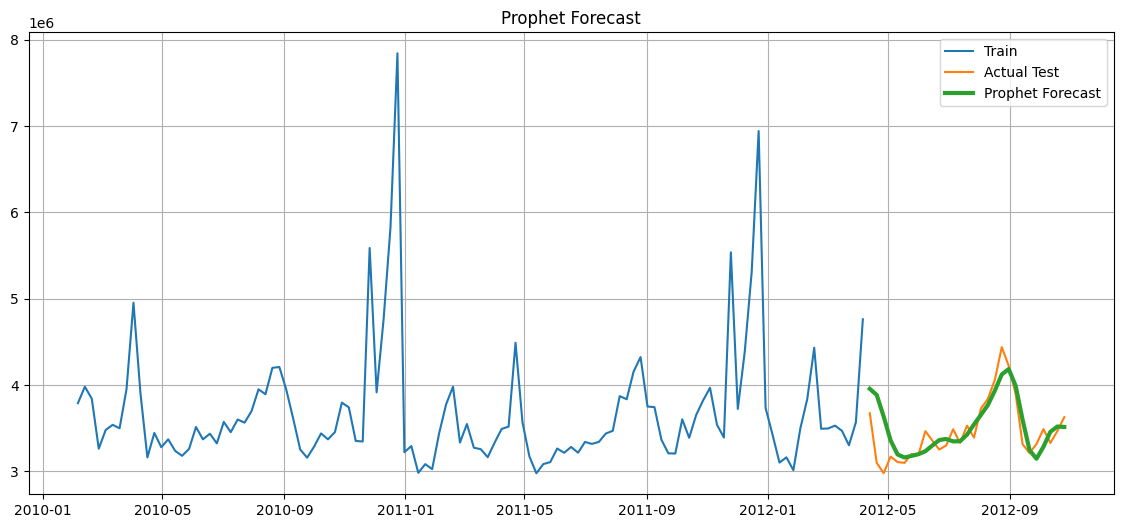

In [49]:
plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train,
    label="Train"
)

plt.plot(
    test.index,
    test,
    label="Actual Test"
)

plt.plot(
    test.index,
    prophet_predictions,
    label="Prophet Forecast",
    linewidth=3
)

plt.title(
    "Prophet Forecast"
)

plt.legend()

plt.grid(True)

plt.show()

In [50]:
mae_prophet = mean_absolute_error(
    test,
    prophet_predictions
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test,
        prophet_predictions
    )
)

mape_prophet = np.mean(

    np.abs(
        (
            test -
            prophet_predictions
        ) / test
    )

) * 100


print("Prophet Results")
print("-" * 40)

print(f"MAE: {mae_prophet:.2f}")

print(f"RMSE: {rmse_prophet:.2f}")

print(f"MAPE: {mape_prophet:.2f}%")

Prophet Results
----------------------------------------
MAE: 161658.64
RMSE: 236881.28
MAPE: 4.80%


In [51]:
# ==========================
# Full Prophet Training
# ==========================

full_prophet = (

    weekly_sales
    .reset_index()
)

full_prophet.columns = [
    "ds",
    "y"
]


# Model
final_prophet = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=False,

    daily_seasonality=False
)


# Train
final_prophet.fit(
    full_prophet
)


print(
    "Final Prophet model trained."
)

17:42:46 - cmdstanpy - INFO - Chain [1] start processing
17:42:46 - cmdstanpy - INFO - Chain [1] done processing


Final Prophet model trained.


In [52]:
# ==========================
# Future Forecast
# ==========================

future_6m = (

    final_prophet
    .make_future_dataframe(
        periods=26,
        freq="W"
    )
)


forecast_6m = (
    final_prophet.predict(
        future_6m
    )
)


print(
    forecast_6m.tail()
)

            ds         trend    yhat_lower    yhat_upper   trend_lower  \
164 2013-03-24  3.641728e+06  3.070850e+06  4.048651e+06  3.641310e+06   
165 2013-03-31  3.641264e+06  3.216307e+06  4.296695e+06  3.640821e+06   
166 2013-04-07  3.640800e+06  3.337699e+06  4.404462e+06  3.640327e+06   
167 2013-04-14  3.640336e+06  3.182596e+06  4.322082e+06  3.639834e+06   
168 2013-04-21  3.639872e+06  2.940844e+06  4.024163e+06  3.639343e+06   

      trend_upper  additive_terms  additive_terms_lower  additive_terms_upper  \
164  3.642188e+06   -97457.187610         -97457.187610         -97457.187610   
165  3.641753e+06   113930.847990         113930.847990         113930.847990   
166  3.641318e+06   215815.719447         215815.719447         215815.719447   
167  3.640883e+06   111080.430386         111080.430386         111080.430386   
168  3.640447e+06  -150051.260742        -150051.260742        -150051.260742   

            yearly   yearly_lower   yearly_upper  multiplicative_ter

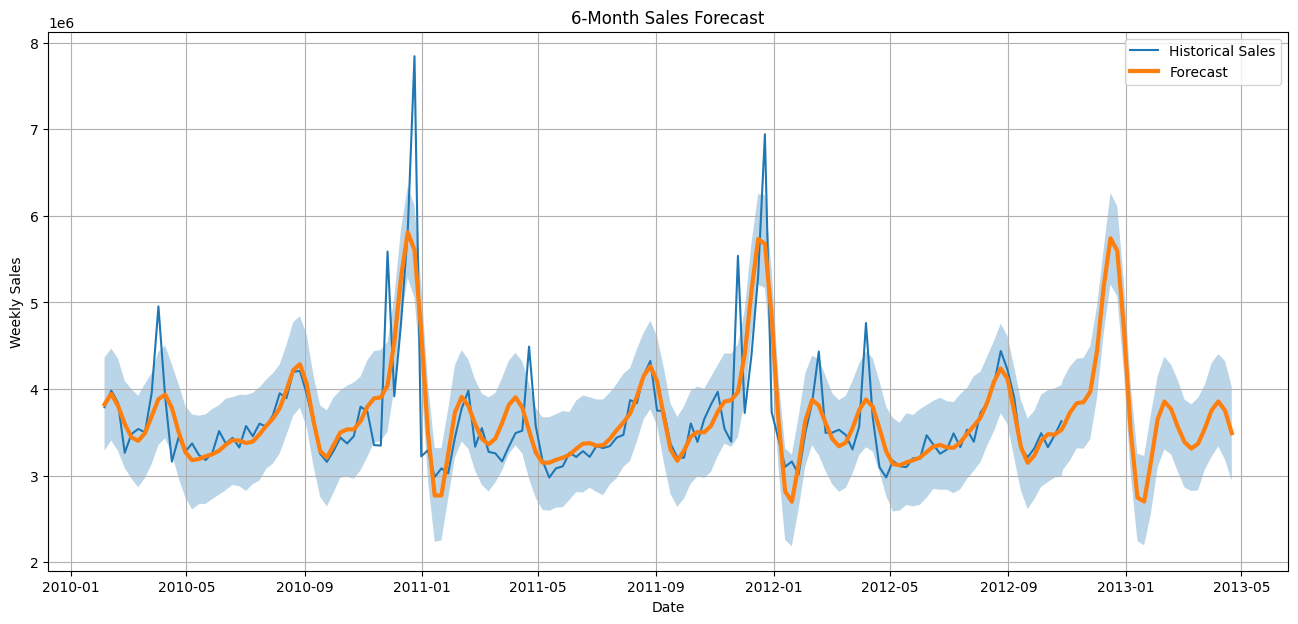

In [53]:
plt.figure(figsize=(16, 7))

plt.plot(
    weekly_sales.index,
    weekly_sales,
    label="Historical Sales"
)

plt.plot(
    forecast_6m["ds"],
    forecast_6m["yhat"],
    label="Forecast",
    linewidth=3
)

plt.fill_between(
    forecast_6m["ds"],
    forecast_6m["yhat_lower"],
    forecast_6m["yhat_upper"],
    alpha=0.3
)

plt.title(
    "6-Month Sales Forecast"
)

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

In [54]:
future_predictions = forecast_6m.tail(26)[

    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]

]

display(
    future_predictions
)

,ds,yhat,yhat_lower,yhat_upper
143,2012-10-28,3.565162e+06,3.072881e+06,4.116842e+06
144,2012-11-04,3.730492e+06,3.176548e+06,4.262328e+06
145,2012-11-11,3.836469e+06,3.315610e+06,4.349961e+06
146,2012-11-18,3.848779e+06,3.311066e+06,4.359547e+06
147,2012-11-25,3.969112e+06,3.419661e+06,4.494163e+06
...,...,...,...,...
164,2013-03-24,3.544271e+06,3.070850e+06,4.048651e+06
165,2013-03-31,3.755195e+06,3.216307e+06,4.296695e+06
166,2013-04-07,3.856616e+06,3.337699e+06,4.404462e+06
167,2013-04-14,3.751416e+06,3.182596e+06,4.322082e+06


In [55]:
# ==========================
# Final Model Comparison
# ==========================

results = pd.DataFrame({

    "Model": [

        "Moving Average",
        "Exponential Smoothing",
        "ARIMA",
        "SARIMA",
        "Prophet"
    ],

    "MAE": [

        mae_ma,
        mae_exp,
        mae_arima,
        mae_sarima,
        mae_prophet
    ],

    "RMSE": [

        rmse_ma,
        rmse_exp,
        rmse_arima,
        rmse_sarima,
        rmse_prophet
    ],

    "MAPE (%)": [

        mape_ma,
        mape_exp,
        mape_arima,
        mape_sarima,
        mape_prophet
    ]
})


results = results.sort_values(
    by="MAPE (%)"
)


display(results)

,Model,MAE,RMSE,MAPE (%)
4,Prophet,1.616586e+05,2.368813e+05,4.804873
1,Exponential Smoothing,2.378346e+05,3.602493e+05,7.127065
0,Moving Average,3.309939e+05,3.810280e+05,9.690565
2,ARIMA,3.799292e+05,4.235260e+05,11.183178
3,SARIMA,1.095979e+06,1.147631e+06,32.576819


In [56]:
best_model = results.iloc[0]

print("Best Forecasting Model")
print("-" * 40)

print(
    f"Model: {best_model['Model']}"
)

print(
    f"MAPE: {best_model['MAPE (%)']:.2f}%"
)

Best Forecasting Model
----------------------------------------
Model: Prophet
MAPE: 4.80%


# Business Recommendations

Based on exploratory data analysis and forecasting results, the following business recommendations are suggested.

## 1. Holiday Inventory Planning

Holiday weeks consistently showed higher sales across all companies.

Recommendation:
- Increase inventory during festive periods.
- Focus on electronics and clothing categories during holidays.
- Plan promotions before major festivals.

---

## 2. City-Level Strategy

Mumbai emerged as the highest-performing city, while Bangalore showed relatively lower sales.

Recommendation:
- Increase inventory allocation for Mumbai stores.
- Improve marketing and customer engagement in Bangalore.
- Analyze successful strategies from Mumbai and replicate in weaker regions.

---

## 3. Department Optimization

Based on inferred department trends:

- Electronics showed strong holiday-driven demand.
- Groceries remained stable throughout the year.
- Clothing exhibited seasonal patterns.
- Books & Stationary showed academic-season spikes.

Recommendation:
- Stock electronics aggressively during festivals.
- Maintain stable grocery inventory.
- Prepare seasonal clothing inventory in advance.
- Promote books/stationary near academic sessions.

---

## 4. Seven Eleven Performance

Seven Eleven consistently recorded the lowest sales.

Recommendation:
- Improve promotional campaigns.
- Introduce festive discounts.
- Replicate successful strategies observed in high-performing stores such as Indore.

---

## 5. Forecast-Based Planning

The Prophet model predicts stable but seasonal future sales.

Recommendation:
- Maintain baseline stock levels.
- Prepare for predictable year-end demand spikes.
- Use forecast confidence intervals for risk-aware inventory management.

# Conclusion

This project analyzed weekly sales data from four retail companies across seven cities and six hidden departments.

The dataset was cleaned, reconstructed, and analyzed using exploratory data analysis techniques to understand business behavior, seasonal trends, holiday effects, and hidden department identities.

Department identities were inferred using sales magnitude, seasonality, and holiday-driven demand patterns.

Multiple forecasting techniques were evaluated, including:

- Moving Average
- Exponential Smoothing
- ARIMA
- SARIMA
- Prophet

Among all methods, the Prophet model achieved the best forecasting performance with a MAPE of approximately 4.8%, making it the most suitable model for predicting future retail sales.

The 6-month forecast suggests relatively stable future sales with recurring seasonal spikes, especially during holiday periods.

These insights can help businesses improve inventory planning, promotional timing, and strategic decision-making.